## [Embedding](https://docs.langchain.com/oss/python/integrations/text_embedding/index#embedding-models)

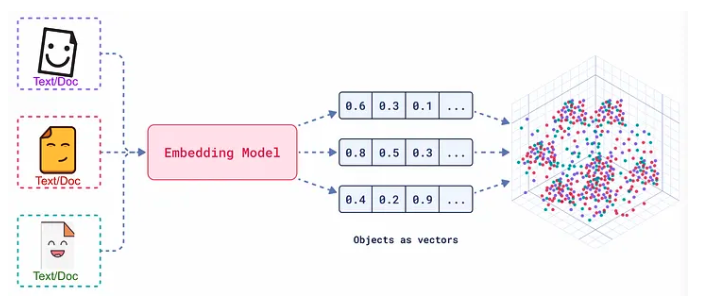

- 임베딩(Embedding)은 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정을 말합니다.
- 이러한 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 되며, 이를 통해 텍스트 간의 유사성을 계산하거나, 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업을 수행할 수 있습니다.
- 임베딩 과정은 텍스트의 의미적인 정보를 보존하도록 설계되어 있어, 벡터 공간에서 가까이 위치한 텍스트 조각들은 의미적으로도 유사한 것으로 간주됩니다.

임베딩의 주요 활용 사례:
- `의미 검색(Semantic Search)`: 벡터 표현을 활용하여 의미적으로 유사한 텍스트를 검색하는 과정으로, 사용자가 입력한 쿼리에 대해 가장 관련성 높은 문서나 정보를 찾아내는 데 사용됩니다.
- `문서 분류(Document Classification)`: 임베딩된 텍스트 벡터를 사용하여 문서를 특정 카테고리나 주제에 할당하는 분류 작업에 사용됩니다.
- `텍스트 유사도 계산(Text Similarity Calculation)`: 두 텍스트 벡터 사이의 거리를 계산하여, 텍스트 간의 유사성 정도를 정량적으로 평가합니다.

임베딩 모델 제공자:
- `OpenAI`: GPT와 같은 언어 모델을 통해 텍스트의 임베딩 벡터를 생성할 수 있는 API를 제공합니다.
- `Hugging Face`: Transformers 라이브러리를 통해 다양한 오픈소스 임베딩 모델을 제공합니다.
- `Google`: Gemini, Gemma 등 언어 모델에 적용되는 임베딩 모델을 제공합니다.

임베딩 메소드:
- `embed_documents`: 이 메소드는 문서 객체의 집합을 입력으로 받아, 각 문서를 벡터 공간에 임베딩합니다. 주로 대량의 텍스트 데이터를 배치 단위로 처리할 때 사용됩니다.
- `embed_query`: 이 메소드는 단일 텍스트 쿼리를 입력으로 받아, 쿼리를 벡터 공간에 임베딩합니다. 주로 사용자의 검색 쿼리를 임베딩하여, 문서 집합 내에서 해당 쿼리와 유사한 내용을 찾아내는 데 사용됩니다.

임베딩은 텍스트 데이터를 머신러닝 모델이 이해할 수 있는 형태로 변환하는 핵심 과정입니다. 다양한 자연어 처리 작업의 기반이 되는 중요한 작업입니다.

# Setup

## API Key 등록 
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [Huggingface 토큰 등록](https://huggingface.co/settings/tokens)

In [1]:
from dotenv import load_dotenv 

load_dotenv()


True

# Embedding 테스트용 함수

In [2]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(a, b):
    return cosine_similarity([a], [b])[0][0]


In [3]:
def test_embedding(embedding_model):
    sentences = [
        '안녕하세요!',
        '어! 오랜만이에요',
        '이름이 어떻게 되세요?',
        '날씨가 추워요',
        'Hello LLM!'
    ]
    query = '첫인사를 하고 이름을 물어봤나요?'
    embeddings = embedding_model.embed_documents(sentences)
    embedded_query = embedding_model.embed_query(query)

    for i, embedding in enumerate(embeddings):
        print(
            f"""
            [유사도 {similarity(embedding, embedded_query):.4f}] {query} \t <=====> \t {sentences[i]}
            """
        )

# [OpenAI Embeddings](https://python.langchain.com/docs/integrations/text_embedding/openai/)
- `OpenAIEmbeddings` 클래스는 OpenAI의 API를 활용하여, 각 문서를 대응하는 임베딩 벡터로 변환합니다.
- `langchain_openai` 라이브러리에서 `OpenAIEmbeddings` 클래스를 직접 임포트합니다.

## [OpenAI Embedding Models](https://platform.openai.com/docs/guides/embeddings/embedding-models#embedding-models)

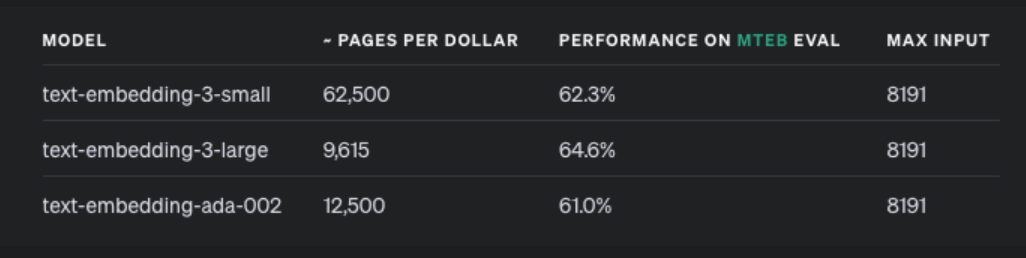

In [4]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

- Embed single text:

In [5]:
input_text = "The meaning of life is 42"
vector = embeddings_model.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1536


In [7]:
# 변환된 벡터 데이터의 일부 확인 
vector[:3]

[0.020976193249225616, -0.02854049764573574, 0.003906212281435728]

- Embed multiple texts:

In [8]:
vectors = embeddings_model.embed_documents(["hello", "goodbye"])
# Showing only the first 3 coordinates
print(f"벡터로 변환된 데이터의 수: {len(vectors)}")
print(f"첫번째 벡터의 데이터 일부 확인: {vectors[0][:3]}")

벡터로 변환된 데이터의 수: 2
첫번째 벡터의 데이터 일부 확인: [0.016751619055867195, -0.055799614638090134, 0.005647437181323767]


## test_embedding 테스트 

In [9]:
test_embedding(embeddings_model)


            [유사도 0.1773] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.1747] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4413] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.0452] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.1410] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


## 차원(dimensions) 조정
- dimensions=1024를 전달함으로써 임베딩의 크기를 1024로 줄일 수 있습니다.

In [10]:
# OpenAI의 "text-embedding-3-small" 모델을 사용하여 1024차원의 임베딩을 생성하는 객체를 초기화합니다.
embeddings_1024 = OpenAIEmbeddings(
    model="text-embedding-3-small", dimensions=1024)


In [11]:
# 주어진 텍스트를 임베딩하고 첫 번째 임베딩 벡터의 길이를 반환합니다.
input_text = "The meaning of life is 42"
len(embeddings_1024.embed_documents([input_text])[0])


1024

- test_embedding

In [12]:
test_embedding(embeddings_1024)


            [유사도 0.2003] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.2063] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4518] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.0748] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.1632] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


# HuggingFace Embeddings
- `sentence-transformers` 라이브러리를 사용하면 HuggingFace 모델에서 사용된 사전 훈련된 임베딩 모델을 다운로드 받아서 적용할 수 있습니다.
- OpenAI 임베딩 모델을 사용할 때는 API 사용료가 부과되지만, HuggingFace의 오픈소스 기반의 임베딩 모델을 사용하면 요금이 부과되지 않습니다.

## [한국어용 임베딩 모델](https://github.com/teddylee777/Kor-IR?tab=readme-ov-file)

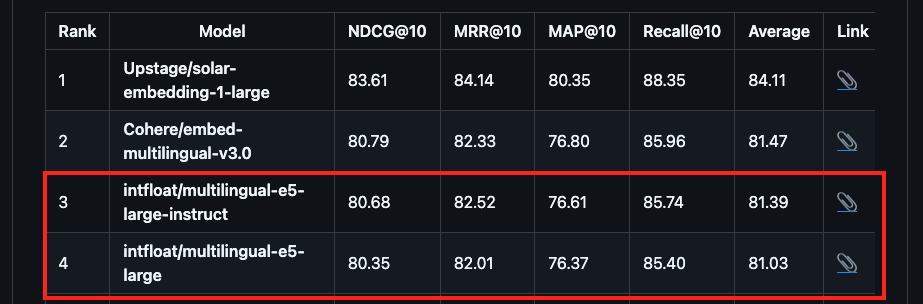

## [HuggingFaceEmbeddings](https://wikidocs.net/231573)

`HuggingFaceEmbeddings` 클래스는 Hugging Face의 트랜스포머 모델을 사용하여 문서 또는 문장을 임베딩하는 데 사용됩니다. 다음은 주요 매개변수의 설정 값을 설명합니다.
- `model_name='jhgan/ko-sroberta-nli'` : 사용할 모델을 지정합니다. 여기서는 한국어 자연어 추론(Natural Language Inference, NLI)에 최적화된 ko-sroberta 모델을 사용합니다.
- `model_kwargs={'device':'cpu'}` : 모델이 CPU에서 실행되도록 설정합니다. GPU를 사용할 수 있는 환경이라면 'cuda'로 설정할 수도 있습니다.
- `encode_kwargs={'normalize_embeddings':True}` : 임베딩을 정규화하여 모든 벡터가 같은 범위의 값을 갖도록 합니다. 이는 유사도 계산 시 일관성을 높여줍니다.

In [17]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

model_name = "intfloat/multilingual-e5-large-instruct"
embeddings_huggingface = HuggingFaceEmbeddings(
    model_name=model_name,
    cache_folder="./models/",       # 모델이 저장될 폴더 지정
    model_kwargs={"device": "cpu"},
    encode_kwargs={'normalize_embeddings':True},
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\dev\github\course_LLM\4. RAG\1. colab\2. Advanced RAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\dev\github\course_LLM\4. RAG\1. colab\2. Advanced RAG\models\models--intfloat--multilingual-e5-large-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_xlm-roberta_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

In [21]:
input_text = "The meaning of life is 42"
vector = embeddings_huggingface.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1024


- test_embedding

In [22]:
test_embedding(embeddings_huggingface)


            [유사도 0.8796] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.8569] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.9217] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.8294] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.8162] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


# [Ollama](https://python.langchain.com/docs/integrations/text_embedding/ollama/)
- Ollama는 로컬 환경에서 대규모 언어 모델(LLM)을 쉽게 실행할 수 있게 해주는 오픈소스 프로젝트입니다.
- 이 도구는 다양한 LLM을 간단한 명령어로 다운로드하고 실행할 수 있게 해주며, 개발자들이 AI 모델을 자신의 컴퓨터에서 직접 실험하고 사용할 수 있도록 지원합니다.
- Ollama는 사용자 친화적인 인터페이스와 빠른 성능으로, AI 개발 및 실험을 더욱 접근하기 쉽고 효율적으로 만들어주는 도구입니다.

## [Ollama Embedding model](https://ollama.com/search?c=embedding)

```shell
# 설치
ollama pull qwen3-embedding

# 확인 
ollama list
```

In [23]:
from langchain_ollama import OllamaEmbeddings

In [24]:
embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [25]:
input_text = "The meaning of life is 42"
vector = embeddings_ollama.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1024


- test_embedding

In [26]:
test_embedding(embeddings_ollama)


            [유사도 0.3798] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.3833] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4712] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.2668] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.3474] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


# [그외 Embedding models](https://python.langchain.com/docs/integrations/text_embedding/)

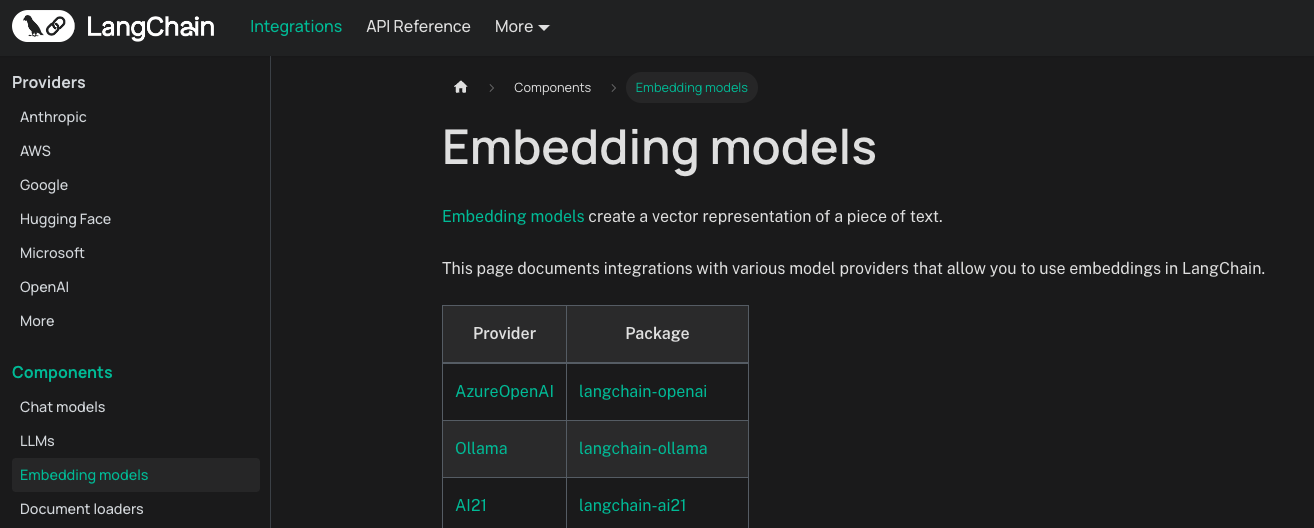

## [Upstage](https://python.langchain.com/docs/integrations/text_embedding/upstage/)
- Upstage는 인공지능(AI) 기술, 특히 대규모 언어 모델(LLM)과 문서 AI 분야에 특화된 국내 스타트업입니다.

## [GPT4All](https://python.langchain.com/docs/integrations/text_embedding/gpt4all/)
- GPT4All은 무료로 사용할 수 있는 로컬 실행 기반의 개인정보 보호를 고려한 챗봇입니다.
- GPU나 인터넷 연결이 필요하지 않으며, GPT4All Falcon, Wizard 등 인기 있는 모델과 자체 모델을 제공합니다.

## [Google Generative AI Embeddings](https://python.langchain.com/docs/integrations/text_embedding/google_generative_ai/)
- GoogleGenerativeAIEmbeddings 클래스를 사용하면 Google의 생성형 AI 모델을 활용하여 문서나 문장을 임베딩할 수 있습니다.